In [66]:
import os
import pickle
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from RRAM import Representate as rp

In [67]:
# Estado inicial de la simulación reset para las vacantes
ruta_raiz = os.getcwd() + "/Estado_inicial.pdf"
print("Ruta raiz del proyecto:", ruta_raiz)

with open("Init_data/init_state_0.pkl", "rb") as file:
    # Carga el contenido del archivo
    initial_configuration = pickle.load(file)

rp.RepresentateState(initial_configuration, 0.00, ruta_raiz)


Ruta raiz del proyecto: c:\Users\Usuario\Documents\GitHub\RRAM_Simulation/Estado_inicial.pdf


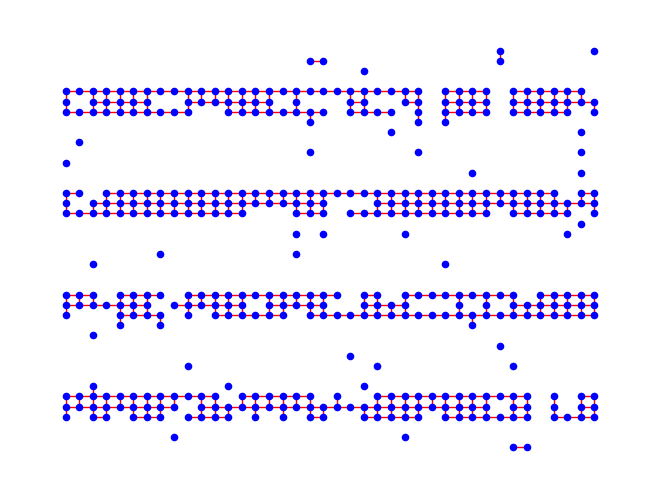

In [68]:
# Crear grafo no dirigido
G = nx.Graph()

grid = np.array(initial_configuration)
H, W = grid.shape
dirs = [(1, 0), (0, 1), (-1, 0), (0, -1)]  # movimientos ortogonales

for i in range(H):
    for j in range(W):
        if grid[i, j] == 1:  # solo celdas caminables
            G.add_node((i, j))  # agregamos el nodo
            for di, dj in dirs:
                ni, nj = i + di, j + dj
                if 0 <= ni < H and 0 <= nj < W and grid[ni, nj] == 1:
                    G.add_edge((i, j), (ni, nj))  # agregamos arista bidireccional
                    
pos = {(i, j): (j, i) for i, j in G.nodes()}  # -i para invertir el eje y si quiere
nx.draw(G, pos=pos, node_size=20, node_color="blue", edge_color="red")
plt.show()

Número de componentes conectados: 5


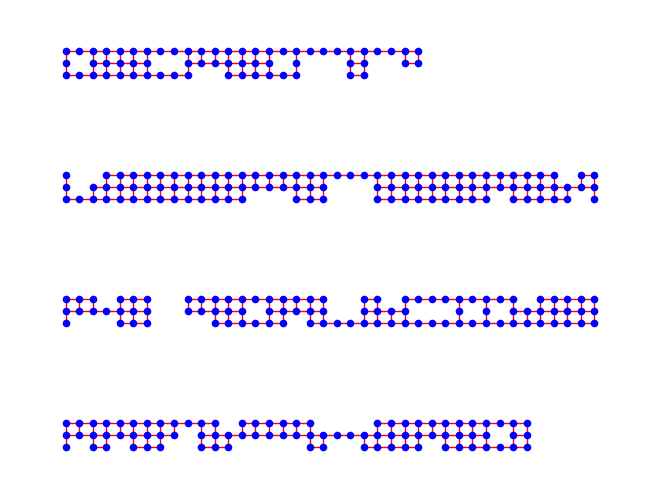

In [69]:
# ELimino los nodos que no tienen aristas
G.remove_nodes_from(list(nx.isolates(G)))

componentes = list(nx.connected_components(G))
validos = [c for c in componentes if len(c) > 20]
nodos_finales = set().union(*validos)
G = G.subgraph(nodos_finales).copy()

print("Número de componentes conectados:", len(validos))

# Nodos con grado 1 (hojas), excluyendo primera y última columna
while True:
    # Encontrar nodos hoja excluyendo primera y última columna
    leaf_nodes = [n for n, d in G.degree() if d == 1 and n[1] not in (0, W - 1)]

    # Si no hay más nodos hoja, salir del bucle
    if not leaf_nodes:
        break

    # Eliminar los nodos hoja encontrados
    G.remove_nodes_from(leaf_nodes)

nx.draw(G, pos=pos, node_size=20, node_color="blue", edge_color="red")
plt.show()

In [70]:
# Crear matriz vacía de ceros
clean_grid = np.zeros((H, W), dtype=int)

# Poner 1 en las posiciones de los nodos que siguen en G
for i, j in G.nodes():
    clean_grid[i, j] = 1

rp.RepresentateState(clean_grid, 0.00, os.getcwd() + "/Estado_inicial_filtro.pdf")

In [ ]:
import networkx as nx
import numpy as np


def obtener_caminos_filamentos(config_matrix, filamentos_ranges, min_size: int = 20):
    # Preparar el grafo no dirigido (A-B es igual que B-A)
    G = nx.Graph()
    grid = np.array(config_matrix)
    H, W = grid.shape
    dirs = [(1, 0), (0, 1), (-1, 0), (0, -1)]  # movimientos ortogonales

    # Creo el grid de nodos a partir de la matriz de configuracion
    for i in range(H):
        for j in range(W):
            if grid[i, j] == 1:  # solo celdas caminables
                G.add_node((i, j))  # agregamos el nodo
                for di, dj in dirs:
                    ni, nj = i + di, j + dj
                    if 0 <= ni < H and 0 <= nj < W and grid[ni, nj] == 1:
                        G.add_edge((i, j), (ni, nj))  # agregamos arista bidireccional

    # Elimino los nodos que no tienen aristas
    G.remove_nodes_from(list(nx.isolates(G)))

    # ELimino componentes pequeños sueltos
    componentes = list(nx.connected_components(G))
    validos = [c for c in componentes if len(c) > min_size]
    
    nodos_finales = set().union(*validos)
    G = G.subgraph(nodos_finales).copy()

    # Nodos con grado 1 (hojas), excluyendo primera y última columna
    while True:
        # Encontrar nodos hoja excluyendo primera y última columna
        leaf_nodes = [n for n, d in G.degree() if d == 1 and n[1] not in (0, W - 1)]

        # Si no hay más nodos hoja, salir del bucle
        if not leaf_nodes:
            break

        # Eliminar los nodos hoja encontrados
        G.remove_nodes_from(leaf_nodes)
        
    # pos = {(i, j): (j, i) for i, j in G.nodes()}  # -i para invertir el eje y si quiere
    # nx.draw(G, pos=pos, node_size=20, node_color="blue", edge_color="red")
    # plt.show()

    # Nodos de origen y destino
    nodos_inicio = [n for n in G.nodes() if n[1] == 0]
    nodos_fin = [n for n in G.nodes() if n[1] == W - 1]

    # Clasificación de nodos de inicio en filamentos
    nodos_inicio_clasificados = {}
    for nodo in nodos_inicio:
        fila = nodo[0]
        filamento_asignado = None
        for idx, (fila_min, fila_max) in enumerate(filamentos_ranges, start=1):
            # TODO: debatible, poner directamente todo el rango? que son 4 bn pero con dos ya daría problemas
            if fila_min - 3 <= fila <= fila_max + 3:  # tolerancia ±3 
                filamento_asignado = idx
                break
        if filamento_asignado is None:
            raise ValueError(f"Nodo {nodo} no pudo asignarse a ningún filamento")
        nodos_inicio_clasificados[nodo] = filamento_asignado

    resultados = {}
    for nodo, filamento in nodos_inicio_clasificados.items():
        percola = any(nx.has_path(G, nodo, t) for t in nodos_fin)
        resultados[nodo] = {"filamento": filamento, "percola": percola}

    return resultados


filamentos_ranges = [(3, 6), (12, 15), (21, 24), (32, 35)]
resultados = obtener_caminos_filamentos(initial_configuration, filamentos_ranges)

for nodo, info in resultados.items():
    print(f"Nodo inicio: {nodo}, Filamento: {info['filamento']}, Percola: {info['percola']}")
    

Nodo inicio: (3, 0), Filamento: 1, Percola: False
Nodo inicio: (4, 0), Filamento: 1, Percola: False
Nodo inicio: (5, 0), Filamento: 1, Percola: False
Nodo inicio: (13, 0), Filamento: 2, Percola: False
Nodo inicio: (14, 0), Filamento: 2, Percola: False
Nodo inicio: (15, 0), Filamento: 2, Percola: False
Nodo inicio: (23, 0), Filamento: 3, Percola: True
Nodo inicio: (24, 0), Filamento: 3, Percola: True
Nodo inicio: (25, 0), Filamento: 3, Percola: True
Nodo inicio: (33, 0), Filamento: 4, Percola: False
Nodo inicio: (34, 0), Filamento: 4, Percola: False
Nodo inicio: (35, 0), Filamento: 4, Percola: False


In [ ]:
def Existe_filamentos(resultados, num_filamentos):
    """
    Comprueba si cada filamento tiene al menos un nodo de inicio que percola.

    Args:
        resultados : dict
            Diccionario { nodo: {"filamento": i, "percola": True/False} }
        num_filamentos : int
            Número total de filamentos

    Returns:
        lista_bool : list
            Lista de booleanos [F1, F2, ...] indicando si cada filamento tiene
            al menos un nodo que percola
    """
    lista_bool = []

    for i in range(1, num_filamentos + 1):
        existe = any(
            info["filamento"] == i and info["percola"] for info in resultados.values()
        )
        lista_bool.append(existe)

    return lista_bool

num_filamentos = len(filamentos_ranges)
resumen = Existe_filamentos(resultados, num_filamentos)
print(resumen)

[False, False, True, False]
